In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──

from pathlib import Path

_HERE = Path.cwd().resolve()
_REPO = next(
    d for d in [_HERE, *_HERE.parents]
    if (d / "studies" / "garlic" / "garlic.py").is_file()
)
DB_PATH = str(_REPO / "data" / "probes" / "garlic_pharmacology.db")
if not Path(DB_PATH).is_file():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")
conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)


# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score.

    Unrecognized/missing labels return NaN (excluded from means) rather than
    0.0, to avoid silently biasing averages toward neutral.
    """
    return SENTIMENT_SCORE.get(s, np.nan)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score is None or pd.isna(avg_score):
        return None
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if pd.isna(k) or pd.isna(n) or n <= 0 or k < 0 or k > n:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0.0, center - margin), min(1.0, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal, inverted, or invalid."""
    if pd.isna(treatment_rate) or pd.isna(baseline_rate):
        return None
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors — include both aggregated ("mixed/neutral") and raw DB labels
# ("mixed", "neutral") so charts can key off either without a KeyError.
COLORS = {
    "positive": "#2ecc71",
    "mixed/neutral": "#95a5a6",
    "mixed": "#95a5a6",
    "neutral": "#95a5a6",
    "negative": "#e74c3c",
}


**Research Question:** "When people in long-COVID and ME/CFS forums talk about garlic,
are they describing one treatment—or several different stories, risks, and experiences?"

# Garlic means two very different things in long-COVID forums

**Abstract.** We reviewed a model-assisted extraction of garlic discussions from 1,928
Reddit accounts in long-COVID and ME/CFS communities. The clearest finding is that
“garlic” does not describe one shared treatment story: one group discusses taking it,
while another discusses it as a trigger food, and their framing differs sharply even
after correcting an overstated result in an earlier analysis. A separate safety signal
deserves attention: 113 of 640 use-reporting accounts also mentioned a blood thinner or
clot-targeting enzyme in their garlic-related text, while explicit warnings were rare.
The practical recommendation is to treat these posts as evidence about community beliefs
and reporting gaps—not as evidence that garlic works—and to discuss possible bleeding
interactions with a clinician.

**Plain-language verdict:** This dataset reveals distinct ways people *talk about* garlic,
plus a potentially important safety-communication gap. It cannot tell us whether garlic
treats long COVID or how often it causes harm.

In [2]:
import collections
import hashlib
import json
import re
import sys
from datetime import datetime, timezone
from pathlib import Path

from matplotlib.lines import Line2D
from scipy.stats import fisher_exact
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, str(_REPO / "studies" / "garlic"))
import garlic as G

G.apply_style(plt)
plt.rcParams.update({
    "figure.figsize": (9.4, 5.1),
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titleweight": "bold",
})

F = G.load_frames(path=Path(DB_PATH), run_id=G.RUN_ID)
COMPLETE = pd.Index(
    F.units.loc[F.units.status.eq("complete"), "reporter"].unique()
)
N_COMPLETE = len(COMPLETE)
USE = F.claims.loc[F.claims.use_payload_allowed].copy()
N_USE = USE.reporter.nunique()
BELIEF = F.claims.loc[
    F.claims.included.astype(bool) & F.claims.polarity.notna()
].copy()
N_BELIEF = BELIEF.reporter.nunique()
ACTS = (
    G.reporter_matrix(F, "speech_act", G.SPEECH_ACTS)
    .reindex(COMPLETE, fill_value=False)
    .astype(bool)
)
ONLY_FOOD = ACTS["food_list"] & ~ACTS["actual_use"]
ONLY_USE = ACTS["actual_use"] & ~ACTS["food_list"]

PALETTE = {
    "blue": "#2563eb",
    "navy": "#163a63",
    "red": "#c2413b",
    "orange": "#d97706",
    "green": "#2f855a",
    "teal": "#0f766e",
    "gray": "#7a8794",
    "light": "#dbe7f3",
}

def fmt_p(value):
    return f"{value:.2e}" if value < 0.001 else f"{value:.3f}"

def fisher_summary(k1, n1, k2, n2):
    table = np.array([[k1, n1 - k1], [k2, n2 - k2]], dtype=int)
    odds_ratio, p_value = fisher_exact(table)
    ci_low, ci_high = Table2x2(table).oddsratio_confint()
    h = G.cohens_h(k1 / n1, k2 / n2)
    return {
        "odds_ratio": float(odds_ratio),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "p": float(p_value),
        "h": float(h),
    }

def html_table(frame, formats=None, caption=None):
    out = frame.copy()
    for column, formatter in (formats or {}).items():
        if column in out:
            out[column] = out[column].map(formatter)
    cap = (
        f"<p style='color:#4b5563;margin:0 0 7px 0'>{caption}</p>"
        if caption else ""
    )
    display(HTML(
        cap
        + out.to_html(
            index=False,
            escape=True,
            border=0,
            classes="dataframe",
        )
    ))

def callout(title, text, color="#2563eb", background="#eff6ff"):
    display(HTML(
        f"<div style='border-left:5px solid {color};background:{background};"
        f"padding:12px 15px;margin:12px 0;border-radius:3px'>"
        f"<b>{title}</b> {text}</div>"
    ))

# Dates come from source metadata only; post bodies are never loaded here.
probe_windows = pd.read_sql_query(
    "SELECT source_type, source_id FROM source_window WHERE run_id = ?",
    conn,
    params=(G.RUN_ID,),
)
reddit_path = _REPO / "reddit_2026-06-13.db"
reddit = sqlite3.connect(f"file:{reddit_path}?mode=ro", uri=True)
all_dates = []
for source_type, table in (("post", "posts"), ("comment", "comments")):
    source_ids = probe_windows.loc[
        probe_windows.source_type.eq(source_type), "source_id"
    ].astype(str).tolist()
    for start in range(0, len(source_ids), 800):
        chunk = source_ids[start:start + 800]
        placeholders = ",".join("?" for _ in chunk)
        all_dates.extend(
            row[0] for row in reddit.execute(
                f"SELECT created_utc FROM {table} "
                f"WHERE id IN ({placeholders})",
                chunk,
            )
            if row[0] is not None
        )
reddit.close()
date_series = pd.to_datetime(
    pd.Series(all_dates, dtype=float), unit="s", utc=True
)
date_low = date_series.min().date().isoformat()
date_high = date_series.max().date().isoformat()
month_span = (
    (date_series.max() - date_series.min()).days / 30.44
)
year_counts = (
    date_series.dt.year.value_counts().sort_index()
    .rename_axis("year").rename("windows").reset_index()
)
recent_share = date_series.dt.year.ge(2021).mean()

# Reduce private window text to three account-level flags, then discard it.
def private_text_flags():
    anticoagulant_pattern = re.compile(
        r"nattokinase|serrapeptase|serrazime|lumbrokinase|bromelain|"
        r"aspirin|warfarin|eliquis|apixaban|xarelto|rivaroxaban|"
        r"clopidogrel|plavix|heparin",
        re.IGNORECASE,
    )
    smell_pattern = re.compile(
        r"parosmi|phantosmi|anosmi|smell (loss|training)|"
        r"lost (my )?(sense of )?(smell|taste)|"
        r"taste(s)? like (wet )?(garbage|rot|chemical|sewage|gasoline)|"
        r"distorted (smell|taste)",
        re.IGNORECASE,
    )
    garlic_pattern = re.compile(
        r"garlic|allicin|kyolic", re.IGNORECASE
    )
    private = G.open_db(Path(DB_PATH))
    reporter_ids = {}
    for (author_hash,) in private.execute(
        "SELECT author_hash FROM cohort_member WHERE run_id = ?",
        (G.RUN_ID,),
    ):
        reporter_ids.setdefault(author_hash, len(reporter_ids))
    for (author_hash,) in private.execute(
        "SELECT author_hash FROM unit WHERE run_id = ?",
        (G.RUN_ID,),
    ):
        reporter_ids.setdefault(author_hash, len(reporter_ids))
    unit_status = dict(private.execute(
        "SELECT unit_key, status FROM unit WHERE run_id = ?",
        (G.RUN_ID,),
    ))
    unit_reporter = {
        unit_key: reporter_ids[author_hash]
        for unit_key, author_hash in private.execute(
            "SELECT unit_key, author_hash FROM unit WHERE run_id = ?",
            (G.RUN_ID,),
        )
    }
    buffers = collections.defaultdict(list)
    for unit_key, text in private.execute(
        "SELECT unit_key, text FROM source_window WHERE run_id = ?",
        (G.RUN_ID,),
    ):
        if unit_status.get(unit_key) == "complete":
            buffers[unit_reporter[unit_key]].append(text or "")
    private.close()
    rows = {}
    for reporter, parts in buffers.items():
        blob = " ".join(parts)
        rows[reporter] = {
            "anticoagulant": bool(anticoagulant_pattern.search(blob)),
            "smell_taste": bool(smell_pattern.search(blob)),
            "garlic_tokens": len(garlic_pattern.findall(blob)),
        }
    return pd.DataFrame.from_dict(rows, orient="index")

TEXT_FLAGS = private_text_flags()

# Rebuild only the private hash-to-dense-ID map needed to match the prior
# JSON extraction. The hashes are discarded before any output is produced.
private = G.open_db(Path(DB_PATH))
reporter_ids = {}
for (author_hash,) in private.execute(
    "SELECT author_hash FROM cohort_member WHERE run_id = ?",
    (G.RUN_ID,),
):
    reporter_ids.setdefault(author_hash, len(reporter_ids))
for (author_hash,) in private.execute(
    "SELECT author_hash FROM unit WHERE run_id = ?",
    (G.RUN_ID,),
):
    reporter_ids.setdefault(author_hash, len(reporter_ids))
private.close()
json_path = (
    _REPO / "data" / "full_corpus_2026-07-31"
    / "records_covidlonghaulers_v2.json"
)
json_garlic_pattern = re.compile(
    r"\bgarlic\b|\ballicin\b|\bkyolic\b|\ballium sativum\b",
    re.IGNORECASE,
)
JSON_REPORTERS = set()
for record in json.loads(json_path.read_text()):
    fields = json.dumps(record.get("fields", {}), ensure_ascii=False)
    if json_garlic_pattern.search(fields):
        reporter = reporter_ids.get(record["record_meta"]["author_hash"])
        if reporter is not None:
            JSON_REPORTERS.add(reporter)
del reporter_ids

## 1. What we looked at

The study began with every non-bot account whose text matched *garlic*, *allicin*, or
*Kyolic*. It did not begin with people already classified as taking garlic, because that
would exclude discussions of trigger foods, recipes, questions, and warnings.

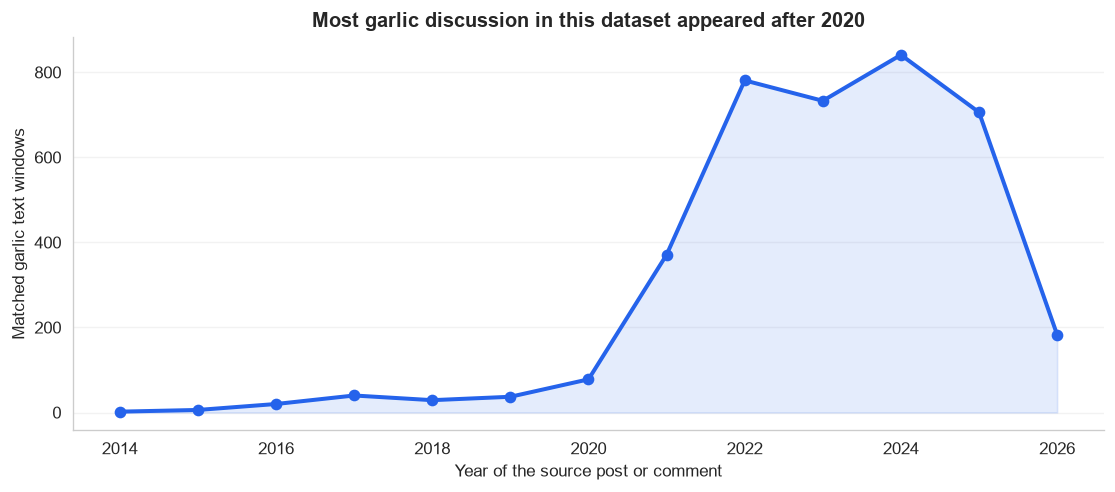

In [3]:
cards = [
    ("1,928", "accounts in the garlic cohort"),
    (f"{N_COMPLETE:,}", "accounts successfully processed"),
    (f"{N_USE:,}", "accounts reporting personal use"),
    (f"{N_BELIEF:,}", "accounts with a garlic belief"),
]
display(HTML(
    "<div style='display:grid;grid-template-columns:repeat(4,1fr);gap:10px;"
    "margin:8px 0 16px'>"
    + "".join(
        "<div style='background:#f7fafc;border:1px solid #dbe7f3;"
        "padding:13px;border-radius:7px;text-align:center'>"
        f"<div style='font-size:1.55em;font-weight:700;color:#163a63'>{value}</div>"
        f"<div style='font-size:.88em;color:#4b5563'>{label}</div></div>"
        for value, label in cards
    )
    + "</div>"
))

fig, ax = plt.subplots(figsize=(9.4, 4.2))
ax.plot(
    year_counts.year,
    year_counts.windows,
    marker="o",
    lw=2.4,
    color=PALETTE["blue"],
)
ax.fill_between(
    year_counts.year,
    year_counts.windows,
    color=PALETTE["blue"],
    alpha=0.12,
)
ax.set_xlabel("Year of the source post or comment")
ax.set_ylabel("Matched garlic text windows")
ax.set_title("Most garlic discussion in this dataset appeared after 2020")
ax.grid(axis="x", visible=False)
fig.tight_layout()
display(fig)
plt.close(fig)

callout(
    "Data coverage.",
    f"Data covers: {date_low} to {date_high} "
    f"({month_span:.0f} months). {recent_share:.0%} of matched, date-linked "
    "text windows are from 2021–2026. Dates describe when people posted, "
    "not when a treatment started or ended.",
    color=PALETTE["navy"],
    background="#f2f6fa",
)

**What this means:** This is a study of how a community discusses garlic, not a
1,928-person treatment trial. The same account can discuss taking garlic, avoiding it,
cooking with it, or asking about it at different times.

## 2. One word, two different worlds

The earlier v1 notebook reported an enormous split between people whose posts looked
like trigger-food lists and people whose posts looked like personal treatment use. But
the model assigned both the post type and the pro/anti framing in the same pass, which
inflated the contrast. The v2 analysis corrected this by taking the group label from one
claim and the pro/anti framing from a different claim by the same account.

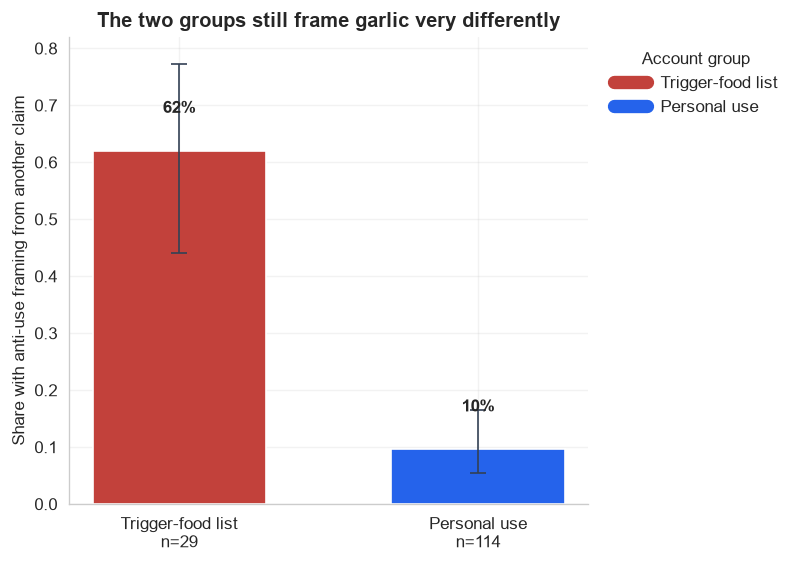

Group,Anti-use framing,Accounts with an independent framing claim,Share
Trigger-food-list accounts,18,29,62.1%
Personal-use accounts,11,114,9.6%


Community explanation,Mostly framed as,Accounts,In that framing
Antimicrobial action,Pro-use,220,195
Blood flow / clotting,Pro-use,165,126
Allium intolerance,Anti-use,74,67
Histamine / MCAS trigger,Anti-use,42,31


In [4]:
def cross_claim_anti_use(mask, excluded_act):
    reporters = set(mask[mask].index)
    eligible = BELIEF.loc[
        BELIEF.reporter.isin(reporters)
        & BELIEF.speech_act.ne(excluded_act)
    ]
    result = eligible.groupby("reporter").polarity.apply(
        lambda values: "anti_use" in set(values)
    )
    return int(result.sum()), int(len(result))

food_anti, food_n = cross_claim_anti_use(ONLY_FOOD, "food_list")
use_anti, use_n = cross_claim_anti_use(ONLY_USE, "actual_use")
split_stats = fisher_summary(food_anti, food_n, use_anti, use_n)
split_rows = pd.DataFrame([
    {
        "Group": "Trigger-food-list accounts",
        "Anti-use framing": food_anti,
        "Accounts with an independent framing claim": food_n,
        "Share": food_anti / food_n,
    },
    {
        "Group": "Personal-use accounts",
        "Anti-use framing": use_anti,
        "Accounts with an independent framing claim": use_n,
        "Share": use_anti / use_n,
    },
])

rates = split_rows["Share"].to_numpy()
intervals = np.array([
    G.wilson(k, n)[1:]
    for k, n in zip(
        split_rows["Anti-use framing"],
        split_rows["Accounts with an independent framing claim"],
    )
])
x = np.arange(2)
fig, ax = plt.subplots(figsize=(8.7, 4.8))
bars = ax.bar(
    x,
    rates,
    width=0.58,
    color=[PALETTE["red"], PALETTE["blue"]],
    yerr=np.vstack([rates - intervals[:, 0], intervals[:, 1] - rates]),
    capsize=5,
    error_kw={"lw": 1, "ecolor": "#334155"},
)
ax.set_xticks(
    x,
    [
        f"Trigger-food list\nn={food_n}",
        f"Personal use\nn={use_n}",
    ],
)
ax.set_ylabel("Share with anti-use framing from another claim")
ax.set_ylim(0, 0.82)
ax.set_title("The two groups still frame garlic very differently")
for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.06,
        f"{rate:.0%}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
ax.legend(
    handles=[
        Line2D([0], [0], color=PALETTE["red"], lw=8, label="Trigger-food list"),
        Line2D([0], [0], color=PALETTE["blue"], lw=8, label="Personal use"),
    ],
    title="Account group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)
fig.tight_layout(rect=[0, 0, 0.78, 1])
display(fig)
plt.close(fig)

html_table(
    split_rows,
    formats={"Share": lambda value: f"{value:.1%}"},
    caption="The denominator is deliberately small: an account needed a second, "
    "different claim from which to read framing.",
)
callout(
    "Plain-language verdict.",
    f"Anti-use framing appeared for {food_anti}/{food_n} "
    f"trigger-food-list accounts ({food_anti / food_n:.0%}) and "
    f"{use_anti}/{use_n} personal-use accounts ({use_anti / use_n:.0%}). "
    "The split is real in this sample, but its exact size is uncertain.",
    color=PALETTE["green"],
    background="#f0fff4",
)
display(HTML(
    "<p><b>Formal comparison.</b> Fisher’s exact test: "
    f"odds ratio {split_stats['odds_ratio']:.1f} "
    f"(95% CI {split_stats['ci_low']:.1f}–{split_stats['ci_high']:.1f}), "
    f"p = {fmt_p(split_stats['p'])}; Cohen’s h = {split_stats['h']:.2f}. "
    "<i>Caution: the trigger-food group has only 29 eligible accounts, so "
    "the direction is more trustworthy than the point estimate.</i></p>"
))

mechanism_counts = (
    F.mechanisms.loc[F.mechanisms.polarity.notna()]
    .drop_duplicates(["reporter", "mechanism", "polarity"])
    .groupby(["mechanism", "polarity"]).reporter.nunique()
    .unstack(fill_value=0)
)
mechanism_examples = pd.DataFrame([
    {
        "Community explanation": "Antimicrobial action",
        "Mostly framed as": "Pro-use",
        "Accounts": int(mechanism_counts.loc["antimicrobial"].sum()),
        "In that framing": int(mechanism_counts.loc["antimicrobial", "pro_use"]),
    },
    {
        "Community explanation": "Blood flow / clotting",
        "Mostly framed as": "Pro-use",
        "Accounts": int(mechanism_counts.loc["cardiovascular_or_bleeding"].sum()),
        "In that framing": int(mechanism_counts.loc["cardiovascular_or_bleeding", "pro_use"]),
    },
    {
        "Community explanation": "Allium intolerance",
        "Mostly framed as": "Anti-use",
        "Accounts": int(mechanism_counts.loc["allium_intolerance"].sum()),
        "In that framing": int(mechanism_counts.loc["allium_intolerance", "anti_use"]),
    },
    {
        "Community explanation": "Histamine / MCAS trigger",
        "Mostly framed as": "Anti-use",
        "Accounts": int(mechanism_counts.loc["histamine_or_mcas_trigger"].sum()),
        "In that framing": int(mechanism_counts.loc["histamine_or_mcas_trigger", "anti_use"]),
    },
])
html_table(
    mechanism_examples,
    caption="Examples of the explanations attached to each side. These are "
    "community claims, not verified biological mechanisms.",
)

**Why the split makes sense:** The two sides are usually not arguing over the same
mechanism. Pro-use posts tend to describe antimicrobial, gut, immune, or blood-flow
ideas. Anti-use posts tend to describe histamine reactions or intolerance to alliums
(the plant family that includes garlic and onions).

**Sensitivity check:** The finding survives the independence check that removed the
original same-claim circularity. Its estimated odds ratio falls from 38.8 in v1 to 15.3
in v2, so the corrected result should replace the old headline.

## 3. The search method can reverse the story

Before this study, a separate automated pass had already marked 500 accounts as having
a garlic-related treatment field. Full-text search found another 1,427 processed
accounts. If we used only the treatment field, the community would look overwhelmingly
like people taking garlic. The full-text group contains much more food-list, recipe, and
symptom discussion.

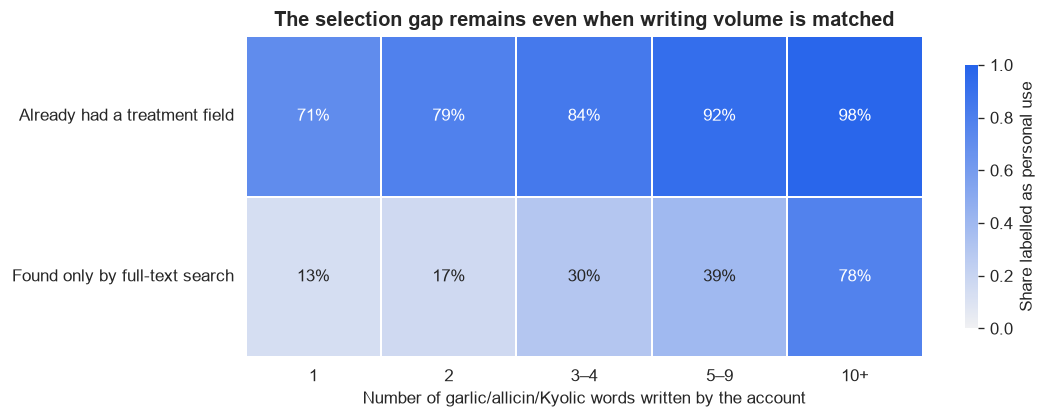

Garlic words written,Treatment-field n,Full-text n,Odds ratio,Fisher p,FDR-adjusted p,Cohen's h
1,206,978,15.6,5.70e-60,2.85e-59,1.25
2,94,233,18.4,3.10e-26,7.74e-26,1.34
3–4,89,137,12.5,3.78e-16,6.30e-16,1.17
5–9,66,61,18.8,8.55e-11,1.07e-10,1.23
10+,45,18,12.6,0.021,0.021,0.68


In [5]:
actual_use = ACTS["actual_use"]
json_accounts = sorted(set(COMPLETE) & JSON_REPORTERS)
full_text_only = sorted(set(COMPLETE) - JSON_REPORTERS)
token_counts = TEXT_FLAGS["garlic_tokens"]
strata = [
    (1, 1, "1"),
    (2, 2, "2"),
    (3, 4, "3–4"),
    (5, 9, "5–9"),
    (10, 10**6, "10+"),
]
method_rows = []
for lower, upper, label in strata:
    prior_group = [
        reporter for reporter in json_accounts
        if lower <= token_counts.get(reporter, 0) <= upper
    ]
    full_text_group = [
        reporter for reporter in full_text_only
        if lower <= token_counts.get(reporter, 0) <= upper
    ]
    prior_positive = int(
        actual_use.reindex(prior_group).fillna(False).sum()
    )
    full_text_positive = int(
        actual_use.reindex(full_text_group).fillna(False).sum()
    )
    stats_row = fisher_summary(
        prior_positive,
        len(prior_group),
        full_text_positive,
        len(full_text_group),
    )
    method_rows.append({
        "Garlic words written": label,
        "Treatment-field n": len(prior_group),
        "Treatment-field use share": prior_positive / len(prior_group),
        "Full-text n": len(full_text_group),
        "Full-text use share": full_text_positive / len(full_text_group),
        **stats_row,
    })
method = pd.DataFrame(method_rows)
method["FDR-adjusted p"] = multipletests(
    method["p"], method="fdr_bh"
)[1]

heat = method.set_index("Garlic words written")[
    ["Treatment-field use share", "Full-text use share"]
].T
fig, ax = plt.subplots(figsize=(9.3, 3.6))
sns.heatmap(
    heat,
    annot=True,
    fmt=".0%",
    cmap=sns.light_palette(PALETTE["blue"], as_cmap=True),
    vmin=0,
    vmax=1,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Share labelled as personal use", "shrink": 0.82},
    ax=ax,
)
ax.set_xlabel("Number of garlic/allicin/Kyolic words written by the account")
ax.set_ylabel("")
ax.set_yticklabels(
    ["Already had a treatment field", "Found only by full-text search"],
    rotation=0,
)
ax.set_title("The selection gap remains even when writing volume is matched")
fig.tight_layout()
display(fig)
plt.close(fig)

method_table = method[[
    "Garlic words written",
    "Treatment-field n",
    "Full-text n",
    "odds_ratio",
    "p",
    "FDR-adjusted p",
    "h",
]].rename(columns={
    "odds_ratio": "Odds ratio",
    "p": "Fisher p",
    "h": "Cohen's h",
})
html_table(
    method_table,
    formats={
        "Odds ratio": lambda value: f"{value:.1f}",
        "Fisher p": fmt_p,
        "FDR-adjusted p": fmt_p,
        "Cohen's h": lambda value: f"{value:.2f}",
    },
    caption="Each row is a separate Fisher exact test. All five remain "
    "significant after Benjamini–Hochberg false-discovery-rate correction.",
)
callout(
    "Plain-language verdict.",
    f"The odds ratio stays between {method.odds_ratio.min():.1f} and "
    f"{method.odds_ratio.max():.1f} in every writing-volume band. "
    "The earlier treatment field was not merely finding people who wrote "
    "more about garlic; it was selecting one kind of garlic story.",
    color=PALETTE["green"],
    background="#f0fff4",
)

**Why this matters beyond garlic:** A database column called “treatment” can quietly
encode a judgment about what counts as treatment. Researchers who build a cohort from
that column may exclude people describing harms, trigger foods, uncertainty, or failed
attempts before the analysis even begins.

**Sensitivity check:** The conclusion holds in every band from one garlic-related word
to ten or more. Among accounts that used the word exactly once, 70.9% of those already
carrying a treatment field were labelled as personal use, versus 13.5% of accounts found
only by full-text search.

## 4. Counterintuitive findings worth investigating

Two findings did not fit the original study design. First, garlic was often discussed
alongside medicines or enzymes used to affect clotting. Second, some “food-list” text was
not about histamine or avoidance at all—it was about long-COVID smell and taste
distortion (parosmia or anosmia).

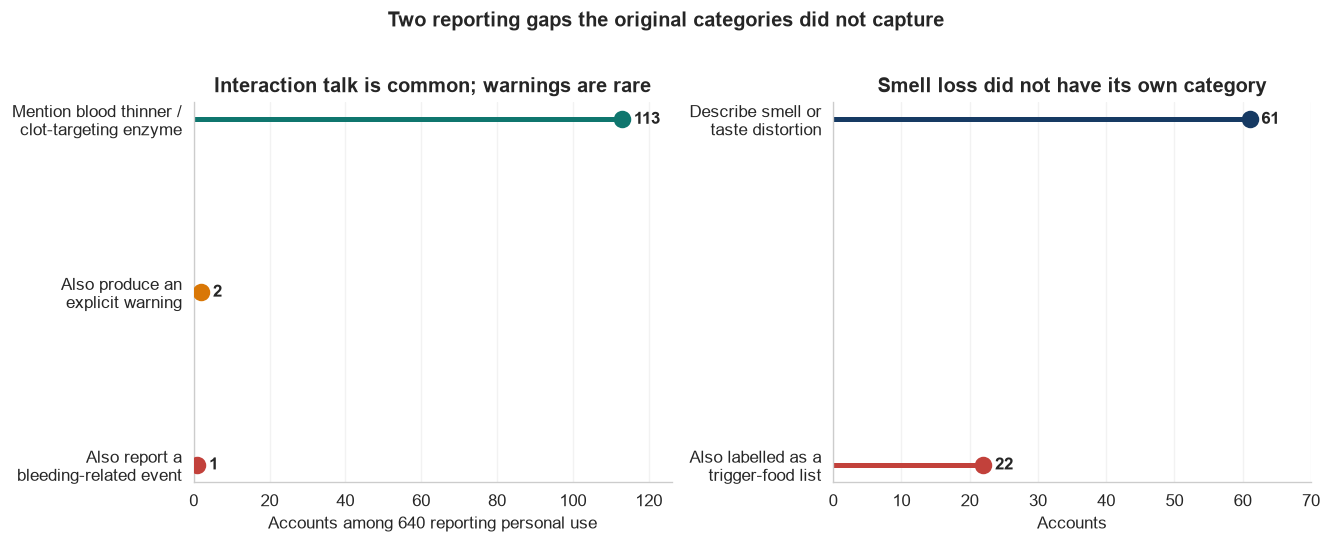

In [6]:
use_reporters = set(USE.reporter)
other_reporters = set(COMPLETE) - use_reporters
anticoagulant_reporters = set(
    TEXT_FLAGS.index[TEXT_FLAGS["anticoagulant"]]
) & set(COMPLETE)
stack_reporters = use_reporters & anticoagulant_reporters
warning_reporters = set(
    F.claims.loc[F.claims.speech_act.eq("warning"), "reporter"]
)
bleeding_reporters = set(
    F.adverse.loc[
        F.adverse.category.eq("bleeding_or_anticoagulant"), "reporter"
    ]
)
safety_stats = fisher_summary(
    len(stack_reporters),
    len(use_reporters),
    len(other_reporters & anticoagulant_reporters),
    len(other_reporters),
)

verbose_reporters = set(
    F.claims.groupby("reporter").size().nlargest(3).index
)
use_sensitivity = use_reporters - verbose_reporters
other_sensitivity = other_reporters - verbose_reporters
sensitivity_stats = fisher_summary(
    len(use_sensitivity & anticoagulant_reporters),
    len(use_sensitivity),
    len(other_sensitivity & anticoagulant_reporters),
    len(other_sensitivity),
)

smell_reporters = set(
    TEXT_FLAGS.index[TEXT_FLAGS["smell_taste"]]
) & set(COMPLETE)
smell_food = smell_reporters & set(ACTS.index[ACTS["food_list"]])

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4))
safety_labels = [
    "Mention blood thinner /\nclot-targeting enzyme",
    "Also produce an\nexplicit warning",
    "Also report a\nbleeding-related event",
]
safety_values = [
    len(stack_reporters),
    len(stack_reporters & warning_reporters),
    len(stack_reporters & bleeding_reporters),
]
safety_colors = [
    PALETTE["teal"],
    PALETTE["orange"],
    PALETTE["red"],
]
y = np.arange(len(safety_labels))[::-1]
for yi, value, color in zip(y, safety_values, safety_colors):
    axes[0].hlines(yi, 0, value, color=color, lw=3)
    axes[0].scatter(value, yi, color=color, s=90, zorder=3)
    axes[0].annotate(
        f"{value}",
        (value, yi),
        xytext=(7, 0),
        textcoords="offset points",
        va="center",
        fontweight="bold",
    )
axes[0].set_yticks(y, safety_labels)
axes[0].set_xlim(0, 126)
axes[0].set_xlabel(f"Accounts among {N_USE} reporting personal use")
axes[0].set_title("Interaction talk is common; warnings are rare")
axes[0].grid(axis="y", visible=False)

smell_labels = [
    "Describe smell or\ntaste distortion",
    "Also labelled as a\ntrigger-food list",
]
smell_values = [len(smell_reporters), len(smell_food)]
y2 = np.arange(len(smell_labels))[::-1]
for yi, value, color in zip(
    y2,
    smell_values,
    [PALETTE["navy"], PALETTE["red"]],
):
    axes[1].hlines(yi, 0, value, color=color, lw=3)
    axes[1].scatter(value, yi, color=color, s=90, zorder=3)
    axes[1].annotate(
        f"{value}",
        (value, yi),
        xytext=(7, 0),
        textcoords="offset points",
        va="center",
        fontweight="bold",
    )
axes[1].set_yticks(y2, smell_labels)
axes[1].set_xlim(0, 70)
axes[1].set_xlabel("Accounts")
axes[1].set_title("Smell loss did not have its own category")
axes[1].grid(axis="y", visible=False)
fig.suptitle(
    "Two reporting gaps the original categories did not capture",
    y=1.02,
    fontweight="bold",
)
fig.tight_layout()
display(fig)
plt.close(fig)

callout(
    "Safety signal—not a measured interaction rate.",
    f"{len(stack_reporters)}/{len(use_reporters)} use-reporting accounts "
    f"({len(stack_reporters) / len(use_reporters):.1%}) also mention an "
    "anticoagulant or clot-targeting enzyme in their garlic-related text. "
    f"Only {len(stack_reporters & warning_reporters)} produce an explicit "
    f"warning claim, and {len(stack_reporters & bleeding_reporters)} report "
    "a bleeding-related event.",
    color=PALETTE["red"],
    background="#fff5f5",
)
display(HTML(
    "<p><b>Formal comparison.</b> Co-mention occurred in "
    f"{len(stack_reporters)}/{len(use_reporters)} personal-use accounts "
    f"versus {len(other_reporters & anticoagulant_reporters)}/"
    f"{len(other_reporters)} other accounts. Fisher’s exact test: odds "
    f"ratio {safety_stats['odds_ratio']:.2f} "
    f"(95% CI {safety_stats['ci_low']:.2f}–{safety_stats['ci_high']:.2f}), "
    f"p = {fmt_p(safety_stats['p'])}; Cohen’s h = {safety_stats['h']:.2f}. "
    "<i>Co-mention does not prove co-ingestion.</i></p>"
))
display(HTML(
    "<p><b>Sensitivity check.</b> After dropping the three accounts with "
    "the most extracted claims, the association remains: odds ratio "
    f"{sensitivity_stats['odds_ratio']:.2f}, "
    f"p = {fmt_p(sensitivity_stats['p'])}. Conclusion holds.</p>"
))
callout(
    "Missing category.",
    f"{len(smell_reporters)} accounts describe smell or taste distortion, "
    f"and {len(smell_food)} of them are also labelled as trigger-food-list "
    "accounts. This regex-based finding is preliminary, but it shows how "
    "“garlic tastes wrong now” can be mistaken for “garlic triggers symptoms.”",
    color=PALETTE["orange"],
    background="#fffbeb",
)

### A quick reality check on “did it help?”

Among the 640 accounts labelled as personal users, more than half did not specify the
form of garlic (330 accounts). The most common stated forms were raw cloves (168),
allicin supplements (104), and the “crush and wait” preparation ritual (33).

Only 301 of the 640 personal-use accounts produced any extractable outcome. Within that
highly selected subset, 215 described help only, 32 worsening only, 25 no effect only,
and 29 mixed or conflicting results. Separately, 106 of 640 mentioned at least one
adverse event, 18 explicitly denied one, and the large remainder said nothing about
side effects.

Those numbers are interesting descriptions of posting behavior, but they are not an
effectiveness or side-effect rate. People who choose to post an outcome differ from
people who stay silent; positive labels are known to be over-called by roughly 10–20%;
and posts naming several treatments can wrongly assign the shared outcome to garlic.
A reporting-based number-needed-to-treat analog is therefore not valid here.

## 5. What patients are saying

To protect privacy, the examples below are **redacted paraphrases** of structured
extraction labels, not searchable quotations. Dates refer to the source post or comment.
Each example names a form and an outcome; the final two deliberately complicate the
positive examples.

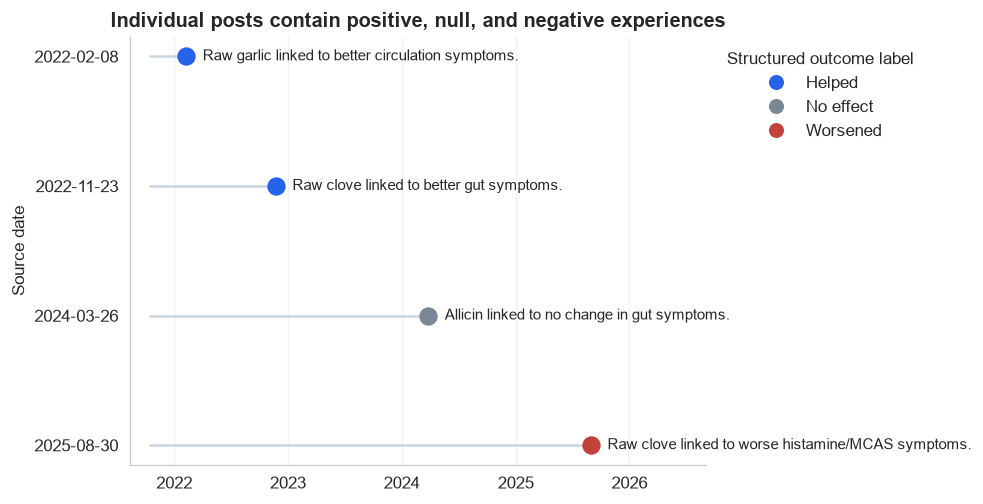

In [7]:
examples = pd.DataFrame([
    {
        "date": "2022-02-08",
        "outcome": "Helped",
        "summary": "A raw-garlic user linked it to improvement in a circulation-related symptom.",
        "chart_summary": "Raw garlic linked to better circulation symptoms.",
    },
    {
        "date": "2022-11-23",
        "outcome": "Helped",
        "summary": "A raw-clove user described improvement in a gut-related symptom.",
        "chart_summary": "Raw clove linked to better gut symptoms.",
    },
    {
        "date": "2024-03-26",
        "outcome": "No effect",
        "summary": "An allicin-supplement user reported no improvement in a gut-related symptom.",
        "chart_summary": "Allicin linked to no change in gut symptoms.",
    },
    {
        "date": "2025-08-30",
        "outcome": "Worsened",
        "summary": "A raw-clove user described worsening of a histamine/MCAS-related symptom.",
        "chart_summary": "Raw clove linked to worse histamine/MCAS symptoms.",
    },
])
examples["date_dt"] = pd.to_datetime(examples["date"])
example_colors = {
    "Helped": PALETTE["blue"],
    "No effect": PALETTE["gray"],
    "Worsened": PALETTE["red"],
}
y = np.arange(len(examples))[::-1]
fig, ax = plt.subplots(figsize=(10.4, 4.3))
ax.hlines(
    y,
    examples.date_dt.min() - pd.Timedelta(days=120),
    examples.date_dt,
    color="#cbd5e1",
    lw=1.5,
)
for yi, row in zip(y, examples.itertuples()):
    ax.scatter(
        row.date_dt,
        yi,
        s=100,
        color=example_colors[row.outcome],
        zorder=3,
    )
    ax.annotate(
        row.chart_summary,
        (row.date_dt, yi),
        xytext=(10, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
    )
ax.set_yticks(y, examples["date"])
ax.set_ylabel("Source date")
ax.set_xlabel("")
ax.set_xlim(
    examples.date_dt.min() - pd.Timedelta(days=180),
    examples.date_dt.max() + pd.Timedelta(days=370),
)
ax.set_title("Individual posts contain positive, null, and negative experiences")
ax.legend(
    handles=[
        Line2D(
            [0], [0], marker="o", color="none",
            markerfacecolor=color, markeredgecolor=color,
            markersize=8, label=label,
        )
        for label, color in example_colors.items()
    ],
    title="Structured outcome label",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
)
ax.grid(axis="y", visible=False)
fig.tight_layout(rect=[0, 0, 0.76, 1])
display(fig)
plt.close(fig)

for row in examples.itertuples():
    display(HTML(
        "<div style='border:1px solid #e2e8f0;border-radius:6px;"
        "padding:10px 12px;margin:7px 0'>"
        f"<b>{row.date} · {row.outcome}</b><br>{row.summary}</div>"
    ))

**What this means:** The aggregate data should not erase disagreement. Even within the
same preparation, people reported benefit, no effect, and worsening. These examples
illustrate the categories; they do not establish how common each experience is.

## 6. What is solid enough to act on

These recommendations concern **how to interpret and study the dataset**, not whether to
take garlic. “Strong” requires a sizeable, statistically supported result; “Moderate”
indicates a clear signal with an important measurement limitation; “Preliminary” means
the finding is mainly a reason to improve the next analysis.

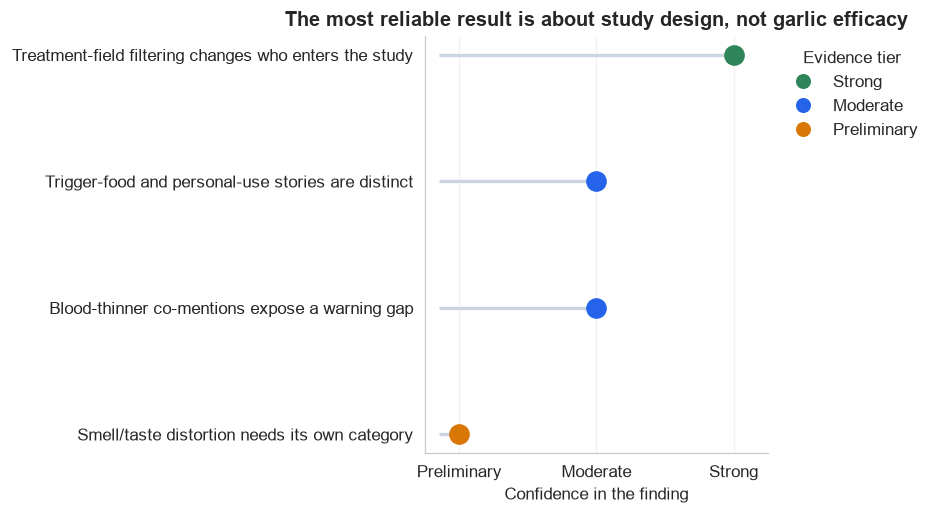

In [8]:
confidence = pd.DataFrame([
    {
        "Finding": "Treatment-field filtering changes who enters the study",
        "Tier": "Strong",
        "Level": 3,
    },
    {
        "Finding": "Trigger-food and personal-use stories are distinct",
        "Tier": "Moderate",
        "Level": 2,
    },
    {
        "Finding": "Blood-thinner co-mentions expose a warning gap",
        "Tier": "Moderate",
        "Level": 2,
    },
    {
        "Finding": "Smell/taste distortion needs its own category",
        "Tier": "Preliminary",
        "Level": 1,
    },
])
tier_colors = {
    "Strong": PALETTE["green"],
    "Moderate": PALETTE["blue"],
    "Preliminary": PALETTE["orange"],
}
y = np.arange(len(confidence))[::-1]
fig, ax = plt.subplots(figsize=(10.2, 4.4))
for yi, row in zip(y, confidence.itertuples()):
    ax.hlines(yi, 0.85, row.Level, color="#cbd5e1", lw=2)
    ax.scatter(
        row.Level,
        yi,
        s=130,
        color=tier_colors[row.Tier],
        zorder=3,
    )
ax.set_yticks(y, confidence["Finding"])
ax.set_xticks([1, 2, 3], ["Preliminary", "Moderate", "Strong"])
ax.set_xlim(0.75, 3.25)
ax.set_xlabel("Confidence in the finding")
ax.set_title("The most reliable result is about study design, not garlic efficacy")
ax.legend(
    handles=[
        Line2D(
            [0], [0], marker="o", color="none",
            markerfacecolor=color, markeredgecolor=color,
            markersize=8, label=tier,
        )
        for tier, color in tier_colors.items()
    ],
    title="Evidence tier",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
)
ax.grid(axis="y", visible=False)
fig.tight_layout(rect=[0, 0, 0.78, 1])
display(fig)
plt.close(fig)

### Conclusion

Garlic is not one story in these communities. It is simultaneously a folk treatment, a
trigger food, a cooking ingredient, a marker of smell loss, and part of a clot-focused
supplement conversation. Collapsing all of that into a single “garlic outcome” would
misrepresent both the people posting and the data.

The strongest lesson is methodological: deciding who counts as a “treatment user” can
determine the conclusion before any statistics are run. Full-text retrieval exposed a
large part of the conversation that the earlier treatment field omitted. The corrected
analysis still finds a major divide between trigger-food and personal-use accounts, but
it is smaller and less precise than v1 claimed.

For a patient, this analysis does **not** support starting garlic for long COVID. It does
support one cautious action: anyone combining garlic with aspirin, prescription blood
thinners, nattokinase, serrapeptase, or similar products should discuss bleeding risk
with a qualified clinician. For researchers, the next step should be to add a
smell/taste-distortion category, adjudicate the weak food-list boundary, and preserve the
full conversation instead of beginning with a preselected treatment cohort.

### Research limitations

| Bias or limitation | How it affects this notebook |
|---|---|
| **Selection bias** | Reddit users who mention garlic are not representative of patients with long COVID or ME/CFS. |
| **Reporting bias** | People choose what to post; unusual successes, failures, and worries may be overrepresented. |
| **Survivorship bias** | Accounts and posts that remain available may differ from deleted or inactive material. |
| **Recall bias** | Posts may describe experiences remembered after the fact rather than recorded prospectively. |
| **Confounding** | Diet, illness severity, other supplements, and medications can explain observed patterns. |
| **No control group** | There is no untreated comparison, randomization, or verified exposure. |
| **Sentiment versus efficacy** | A positive or negative text label is not a clinical outcome measurement. |
| **Temporal snapshot** | The source ends in June 2026 and posting dates do not establish treatment timing. |
| **Positive over-call** | Validation suggests roughly 10–20% of stored positive labels may be false positives; negative labels are more reliable. |
| **Group-attribution inflation** | A post naming several treatments can assign one shared outcome to each item, including garlic. |
| **Extractor instability** | On a small temperature-zero repeat, `speech_act` matched only 79.4% of paired claims. |
| **Weak category gate** | Blind review agreed on only 5 of 12 sampled food-list/avoidance/culinary labels; those cuts remain provisional. |

The anticoagulant and parosmia follow-ups were targeted analyses prompted by v1, not a
broad scan of every possible keyword. Their p-values are unadjusted and the parosmia
result is explicitly hypothesis-generating.

In [9]:
provenance = pd.DataFrame([
    {
        "Provenance item": "Database",
        "Value": Path(DB_PATH).name,
    },
    {
        "Provenance item": "Database SHA-256",
        "Value": hashlib.sha256(Path(DB_PATH).read_bytes()).hexdigest(),
    },
    {
        "Provenance item": "Pinned run ID",
        "Value": G.RUN_ID,
    },
    {
        "Provenance item": "Cohort-member rows",
        "Value": f"{len(F.members):,}",
    },
    {
        "Provenance item": "Unit rows",
        "Value": f"{len(F.units):,}",
    },
    {
        "Provenance item": "Claim rows",
        "Value": f"{len(F.claims):,}",
    },
    {
        "Provenance item": "Source-window rows",
        "Value": f"{int(F.units.windows.sum()):,}",
    },
    {
        "Provenance item": "Source date range",
        "Value": f"{date_low} to {date_high}",
    },
    {
        "Provenance item": "Research-assistant skill",
        "Value": "v2",
    },
    {
        "Provenance item": "Notebook executed (UTC)",
        "Value": datetime.now(timezone.utc).date().isoformat(),
    },
])
html_table(
    provenance,
    caption="Provenance for reproducing this public-facing synthesis.",
)

display(HTML(
    "<p style='font-size:1.2em;font-weight:bold;font-style:italic;"
    "margin-top:1.2em'>These findings reflect reporting patterns in online "
    "communities, not population-level treatment effects. This is not "
    "medical advice.</p>"
))

Provenance item,Value
Database,garlic_pharmacology.db
Database SHA-256,7caae438b3512ea0cb4a59f2956d3417b0b7abfde34a234dfab3e7b3d32eb4f0
Pinned run ID,c05891b6ecad47900230eb606afbb230a9867fc9f41d1d2b88ec0292a05b03df
Cohort-member rows,"1,928"
Unit rows,"1,996"
Claim rows,"3,723"
Source-window rows,"3,873"
Source date range,2014-10-20 to 2026-06-10
Research-assistant skill,v2
Notebook executed (UTC),2026-08-13
